In [1]:
!pip install torchvision

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from PIL import Image
import zipfile
from torch.utils.data import Dataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda')

In [5]:
url = "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"

In [6]:
zip_path = "pizza_steak.zip"

In [7]:
import os
import requests

if not os.path.exists(zip_path):
  response = requests.get(url, stream=True)
  with open(zip_path, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
      f.write(chunk)

In [8]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall()

In [9]:
from pathlib import Path

In [10]:
train_dir = Path("/content/pizza_steak/train")
test_dir = Path("/content/pizza_steak/test")

In [11]:
os.listdir(train_dir)

['pizza', 'steak']

In [12]:
os.listdir(test_dir)

['pizza', 'steak']

In [13]:
len(os.listdir(train_dir / 'pizza'))

750

In [14]:
len(os.listdir(train_dir / 'steak'))

750

In [15]:
len(os.listdir(test_dir / 'pizza'))

250

In [16]:
len(os.listdir(test_dir / 'steak'))

250

In [17]:
# ../pizza_steak/train_dir/pizza/shekil1.png
# ../pizza_steak/train_dir/pizza/shekil2.png
# ../pizza_steak/train_dir/pizza/shekil3.png

In [18]:
def show_random_image(folder_path, class_name):
  class_folder = Path(folder_path) / class_name
  random_image_name = np.random.choice(os.listdir(class_folder))
  img_path = class_folder / random_image_name

  img = Image.open(img_path)
  plt.imshow(img)
  plt.axis('off')
  return np.array(img)

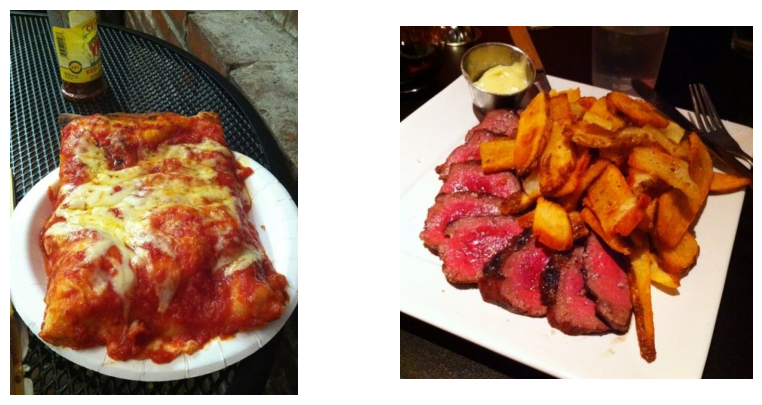

In [19]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
show_random_image('pizza_steak/train', 'pizza')
plt.subplot(1, 2, 2)
show_random_image('pizza_steak/train', 'steak')
plt.show()

In [20]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.optim as optim

In [21]:
# PIL (224, 224, 3) -> (224, 224, 3)

In [22]:
# data transformation

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [23]:
# pizza -> 0
# steak -> 1

In [24]:
# Datasetləri yükləyirik
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

In [25]:
# DataLoader-ləri yaradırıq
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [26]:
images, labels = next(iter(train_loader))

In [27]:
images.shape

torch.Size([32, 3, 224, 224])

In [28]:
labels[:8].tolist()

[1, 1, 0, 1, 0, 1, 1, 0]

In [29]:
# X - X(min) / (X(max) - X(min))

In [30]:
def plot_image(image_tensor):
    img = image_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.axis('off')

In [31]:
class_names = train_dataset.classes
class_names

['pizza', 'steak']

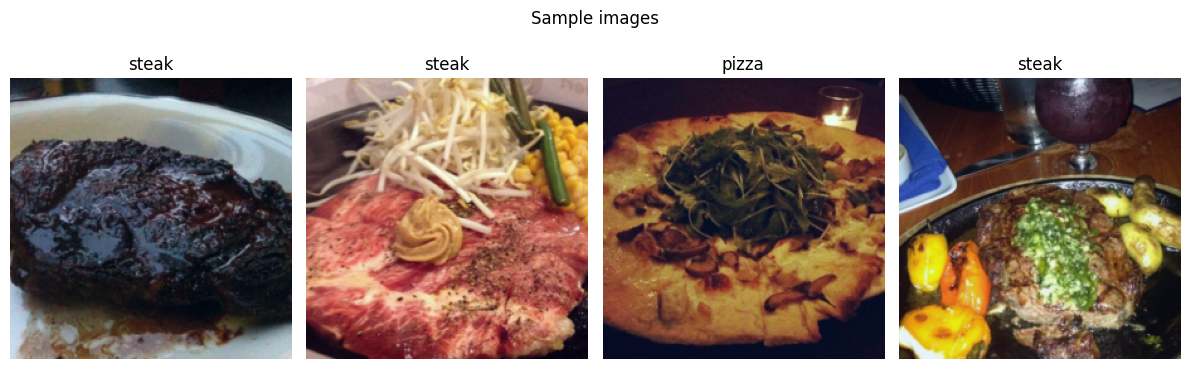

In [32]:
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plot_image(images[i])
    plt.title(class_names[labels[i].item()])
plt.suptitle('Sample images')
plt.tight_layout()
plt.show()

In [33]:
sample_images = images[:2]

In [34]:
import torchvision.transforms.v2 as T

In [35]:
cropped_images = T.CenterCrop((70, 120))(sample_images)
cropped_images.shape

torch.Size([2, 3, 70, 120])

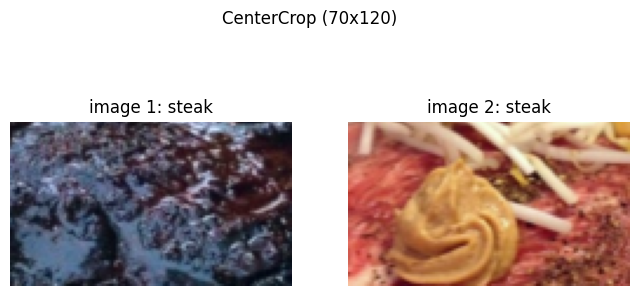

In [36]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.title(f'image 1: {class_names[labels[0].item()]}')
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])
plt.title(f'image 2: {class_names[labels[1].item()]}')
plt.suptitle('CenterCrop (70x120)')
plt.show()

In [37]:
#(224, 224, 3) -> (3, 224, 224)

In [38]:
# (70 - 7 + 1) = 64
# (120 - 7 + 1) = 114

In [39]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7) # -> (7x7)
fmaps = conv_layer(cropped_images)
print('The output form of Conv2d (without padding):', fmaps.shape)

The output form of Conv2d (without padding): torch.Size([2, 32, 64, 114])


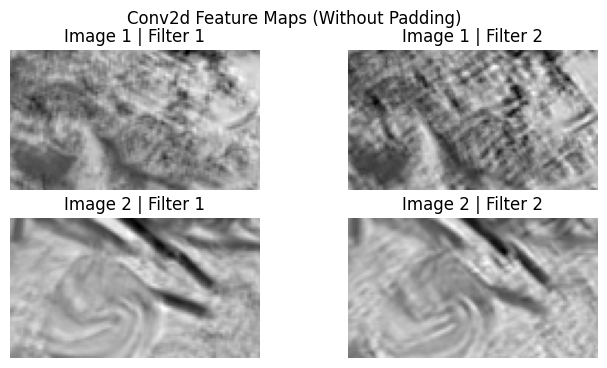

In [40]:
plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap='gray')
        plt.title(f'Image {image_idx+1} | Filter {fmap_idx+1}')
        plt.axis('off')
plt.suptitle('Conv2d Feature Maps (Without Padding)')
plt.show()

In [41]:
conv_layer_same = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding='same')
fmaps_same = conv_layer_same(cropped_images)
fmaps_same.shape

torch.Size([2, 32, 70, 120])

In [42]:
#

In [43]:
# [(70 + (2 * padding) - kernel_size) / (stride)] + 1

In [44]:
conv_layer_stride = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2, padding=3)
fmaps_stride = conv_layer_stride(cropped_images)
print(fmaps_stride.shape)
print(conv_layer_stride.weight.shape)
print(conv_layer_stride.bias.shape)

torch.Size([2, 32, 35, 60])
torch.Size([32, 3, 7, 7])
torch.Size([32])


In [45]:
import torch.nn.functional as F

In [46]:
torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])
biases  = torch.zeros([2])
fmaps_manual = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')
fmaps_manual.shape

torch.Size([2, 2, 70, 120])

In [47]:
filters = torch.zeros([2, 3, 7, 7])
filters[0, :, :, 3] = 1   # bütün kanallar, bütün sıralar, 3-cü sütun = 1
filters[1, :, 3, :] = 1   # bütün kanallar, 3-cü sıra, bütün sütunlar = 1

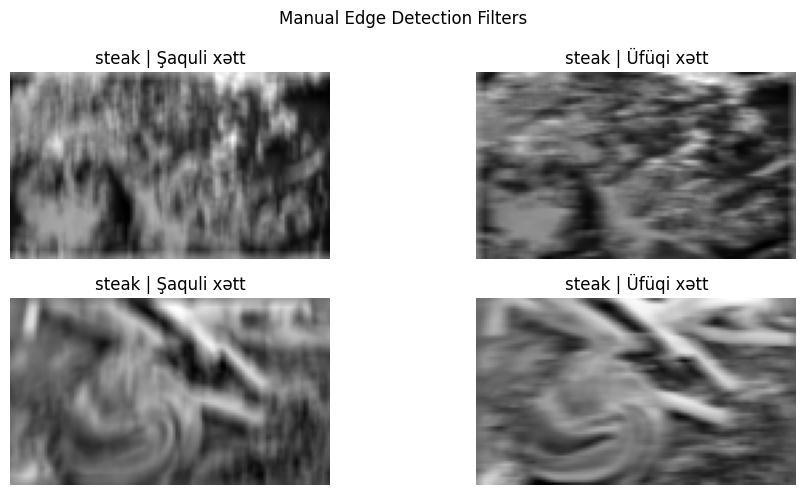

In [48]:
fmaps_edge = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')

plt.figure(figsize=(10, 5))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps_edge[image_idx, fmap_idx].detach(), cmap='gray')
        title = 'Şaquli xətt' if fmap_idx == 0 else 'Üfüqi xətt'
        plt.title(f'{class_names[labels[image_idx].item()]} | {title}')
        plt.axis('off')
plt.suptitle('Manual Edge Detection Filters')
plt.tight_layout()
plt.show()

In [49]:
# MaxPooling
max_pool = nn.MaxPool2d(kernel_size=2)
output_max = max_pool(cropped_images)

print('Original:', cropped_images.shape)
print('MaxPool: ', output_max.shape)

Original: torch.Size([2, 3, 70, 120])
MaxPool:  torch.Size([2, 3, 35, 60])


In [50]:
avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(cropped_images)

print('Original:', cropped_images.shape)
print('AvgPool: ', output_avg.shape)

Original: torch.Size([2, 3, 70, 120])
AvgPool:  torch.Size([2, 3, 35, 60])


Text(0.5, 1.0, 'Original image (steak)')

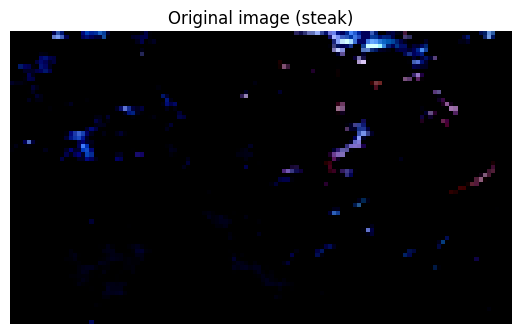

In [51]:
fig = plt.figure(figsize=(10, 6))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1, 2, 0).numpy().clip(0, 1))
ax1.axis('off')
ax1.set_title(f'Original image ({class_names[labels[0].item()]})')

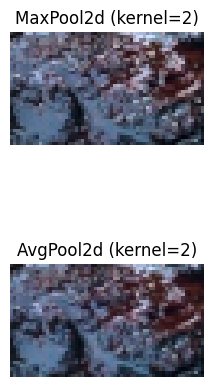

In [52]:
ax2 = plt.subplot2grid((2, 3), (0, 2))
out_max_np = output_max[0].permute(1, 2, 0).detach().numpy()
out_max_np = (out_max_np - out_max_np.min()) / (out_max_np.max() - out_max_np.min())
ax2.imshow(out_max_np)
ax2.axis('off')
ax2.set_title('MaxPool2d (kernel=2)')

ax3 = plt.subplot2grid((2, 3), (1, 2))
out_avg_np = output_avg[0].permute(1, 2, 0).detach().numpy()
out_avg_np = (out_avg_np - out_avg_np.min()) / (out_avg_np.max() - out_avg_np.min())
ax3.imshow(out_avg_np)
ax3.axis('off')
ax3.set_title('AvgPool2d (kernel=2)')

plt.tight_layout()
plt.show()

In [53]:
# Depth-wise Pooling
class DepthMaxPool2(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, inputs):
      batch, channels, height, width = inputs.shape
      Z = inputs.reshape(batch, channels, height * width)
      Z = Z.permute(0, 2, 1)
      Z = F.max_pool1d(Z, kernel_size=self.kernel_size,
                        stride=self.stride, padding=self.padding)
      Z = Z.permute(0, 2, 1)
      return Z.reshape(batch, -1, height, width)

In [54]:
# (RGB - 1) / 2

In [55]:
depth_pool = DepthMaxPool2(kernel_size=3)
output_depth = depth_pool(cropped_images)
print('Original:', cropped_images.shape)
print('DepthPool:', output_depth.shape)

Original: torch.Size([2, 3, 70, 120])
DepthPool: torch.Size([2, 1, 70, 120])


In [56]:
# Gloabl Average Pooling
global_avg_pool_v1 = nn.AvgPool2d(kernel_size=(70, 120))
output_v1 = global_avg_pool_v1(cropped_images)
print(output_v1.shape)

torch.Size([2, 3, 1, 1])


In [57]:
global_avg_pool_v2 = nn.AdaptiveAvgPool2d(output_size=1)
output_v2 = global_avg_pool_v2(cropped_images)
print(output_v2.shape)

torch.Size([2, 3, 1, 1])


In [58]:
output_v3 = cropped_images.mean(dim=(2, 3), keepdim=True)
print(output_v3.shape)

torch.Size([2, 3, 1, 1])


In [59]:
print(torch.allclose(output_v1, output_v2) and torch.allclose(output_v2, output_v3))

True


In [60]:
from functools import partial
import torch
import torch.nn as nn

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")

model = nn.Sequential(
    DefaultConv2d(in_channels=3, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=256 * 28 * 28, out_features=128), nn.ReLU(),  # 224/2/2/2=28
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=1),   # binary: 1 çıxış
    nn.Sigmoid()
).to(device)

In [61]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.0 MB/s eta 0:00:00


In [62]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch.float().view(-1, 1))
    return metric.compute()

In [63]:
def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch.float().view(-1, 1))
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch.float().view(-1, 1))
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch+1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train acc: {history['train_metrics'][-1]:.4f}, "
              f"valid acc: {history['valid_metrics'][-1]:.4f}")
    return history

In [64]:
n_epochs  = 20
optimizer = torch.optim.AdamW(model.parameters())
bce_loss  = nn.BCELoss()
accuracy  = torchmetrics.Accuracy(task="binary").to(device)

history = train(model, optimizer, bce_loss, accuracy,
                train_loader, test_loader, n_epochs)

Epoch 1/20, train loss: 0.6240, train acc: 0.6380, valid acc: 0.7540
Epoch 2/20, train loss: 0.5625, train acc: 0.7380, valid acc: 0.8080
Epoch 3/20, train loss: 0.4938, train acc: 0.7740, valid acc: 0.8300
Epoch 4/20, train loss: 0.4672, train acc: 0.7973, valid acc: 0.8400
Epoch 5/20, train loss: 0.4476, train acc: 0.7973, valid acc: 0.8260
Epoch 6/20, train loss: 0.4288, train acc: 0.8127, valid acc: 0.8080
Epoch 7/20, train loss: 0.4312, train acc: 0.8073, valid acc: 0.8420
Epoch 8/20, train loss: 0.4027, train acc: 0.8213, valid acc: 0.8620
Epoch 9/20, train loss: 0.3723, train acc: 0.8380, valid acc: 0.8300
Epoch 10/20, train loss: 0.3386, train acc: 0.8487, valid acc: 0.8560
Epoch 11/20, train loss: 0.3046, train acc: 0.8620, valid acc: 0.8660
Epoch 12/20, train loss: 0.3014, train acc: 0.8753, valid acc: 0.8360
Epoch 13/20, train loss: 0.2510, train acc: 0.8967, valid acc: 0.8380
Epoch 14/20, train loss: 0.2255, train acc: 0.9060, valid acc: 0.8520
Epoch 15/20, train loss: 0.19

# LeNet

In [65]:
# LeNet modelinin qurulması
class LeNet(nn.Module):
    def __init__(self, input_size=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(input_size, 6, kernel_size=5, padding='same'),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 120, kernel_size=5),
            nn.Flatten(),
            nn.Linear(120 * 50 * 50, 84),  # 224→112→54→50
            nn.Tanh(),
            nn.Linear(84, 1),
            nn.Sigmoid()
        )
    def forward(self, X):
        return self.model(X)

In [66]:
def train_lenet(model, optimizer, loss_fn, train_loader, epochs):
    for epoch in range(epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch.float().view(-1, 1))
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        print(f'Epoch: {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}')

In [67]:
model_lenet = LeNet(3).to(device)
optimizer   = torch.optim.AdamW(model_lenet.parameters(), lr=1e-3)
train_lenet(model_lenet, optimizer, nn.BCELoss(), train_loader, epochs=20)

Epoch: 1/20, Loss: 0.6763
Epoch: 2/20, Loss: 0.5085
Epoch: 3/20, Loss: 0.5033
Epoch: 4/20, Loss: 0.4907
Epoch: 5/20, Loss: 0.4964
Epoch: 6/20, Loss: 0.4893
Epoch: 7/20, Loss: 0.4891
Epoch: 8/20, Loss: 0.5170
Epoch: 9/20, Loss: 0.5596
Epoch: 10/20, Loss: 0.5391
Epoch: 11/20, Loss: 0.5319
Epoch: 12/20, Loss: 0.6100
Epoch: 13/20, Loss: 0.5499
Epoch: 14/20, Loss: 0.5076
Epoch: 15/20, Loss: 0.5103
Epoch: 16/20, Loss: 0.5006
Epoch: 17/20, Loss: 0.5027
Epoch: 18/20, Loss: 0.4981
Epoch: 19/20, Loss: 0.4993
Epoch: 20/20, Loss: 0.5036


In [68]:
images, labels = next(iter(train_loader))
new_data = images[:3].to(device)
preds = model_lenet(new_data)
predicted_classes = (preds > 0.5).long().squeeze()
print("Predictions:", [class_names[i] for i in predicted_classes])
print("Real: ", [class_names[i] for i in labels[:3]])

Predictions: ['steak', 'pizza', 'pizza']
Real:  ['steak', 'pizza', 'steak']


# SeperableConv2D

In [69]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size,
            stride=stride, padding=padding, groups=in_channels)
        self.pointwise_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

# ResNet

In [70]:
import torch.nn.functional as F

class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        DefaultConv2d = partial(nn.Conv2d, kernel_size=3, stride=1, padding=1, bias=False)
        self.main_layers = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, stride=stride),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            DefaultConv2d(out_channels, out_channels),
            nn.BatchNorm2d(out_channels),
        )
        self.skip_connection = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, padding=0),
            nn.BatchNorm2d(out_channels),
        ) if stride > 1 else nn.Identity()

    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

In [71]:
class ResNet34(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        ]
        prev_filters = 64
        for filters in [64]*3 + [128]*4 + [256]*6 + [512]*3:
            stride = 1 if filters == prev_filters else 2
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters
        layers += [
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        ]
        self.resnet = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.resnet(inputs)

In [72]:
torch.manual_seed(42)
model_resnet = ResNet34().to(device)

In [73]:
dummy = torch.randn(2, 3, 224, 224).to(device)
print(model_resnet(dummy).shape)

torch.Size([2, 1])


# Transfer Learning — Pretrained ConvNeXt

In [74]:
import torchvision
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model_convnext = torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 151MB/s]


In [75]:
print(dir(model_convnext))

['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_impl', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members', '_non_persistent_buffers_set', '_parameters', '_register_load_s

In [76]:
# we change the last layer for binary output
model_convnext.classifier[2] = nn.Sequential(
    nn.Linear(1024, 1),
    nn.Sigmoid()
).to(device)

In [77]:
# First, we train the classifier layer
for param in model_convnext.parameters():
    param.requires_grad = False
for param in model_convnext.classifier.parameters():
    param.requires_grad = True

In [78]:
n_epochs  = 5
optimizer = torch.optim.AdamW(model_convnext.parameters())
accuracy  = torchmetrics.Accuracy(task="binary").to(device)
history = train(model_convnext, optimizer, nn.BCELoss(), accuracy,
                train_loader, test_loader, n_epochs)

Epoch 1/5, train loss: 0.2639, train acc: 0.9353, valid acc: 0.9980
Epoch 2/5, train loss: 0.0792, train acc: 0.9807, valid acc: 0.9980
Epoch 3/5, train loss: 0.0584, train acc: 0.9820, valid acc: 0.9980
Epoch 4/5, train loss: 0.0514, train acc: 0.9813, valid acc: 0.9980
Epoch 5/5, train loss: 0.0435, train acc: 0.9900, valid acc: 0.9980


In [79]:
# then, we continue with fine-tuning
for param in model_convnext.parameters():
    param.requires_grad = True

In [80]:
history = train(model_convnext, optimizer, nn.BCELoss(), accuracy,
                train_loader, test_loader, n_epochs)

Epoch 1/5, train loss: 0.6872, train acc: 0.7447, valid acc: 0.9440
Epoch 2/5, train loss: 0.3049, train acc: 0.8820, valid acc: 0.9720
Epoch 3/5, train loss: 0.1911, train acc: 0.9320, valid acc: 0.9760
Epoch 4/5, train loss: 0.1610, train acc: 0.9420, valid acc: 0.9860
Epoch 5/5, train loss: 0.1537, train acc: 0.9420, valid acc: 0.9800


# Data Augmentation

In [81]:
import torchvision.transforms.v2 as T

augmented_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [82]:
# Training with augmentation
from torchvision import datasets
train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=augmented_transform)
train_loader_aug  = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

# Classification and Localization

In [83]:
class PizzaSteakLocator(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        # ConvNeXt modelinin classifier hissəsindəki son linear qatın giriş ölçüsünü alırıq.
        # model_convnext.classifier[2][0] refers to the nn.Linear(1024, 1) layer.
        in_features = self.base_model.classifier[2][0].in_features

        # Lokallaşdırma başlığı (Bounding Box: [x, y, w, h])
        # Flatten əvvəlcədən tətbiq olunacağı üçün burada ehtiyac yoxdur.
        self.localization_head = nn.Sequential(
            nn.Linear(in_features, 4)
        )

    def forward(self, x):
        # Xüsusiyyətləri ConvNeXt-in öz feature extractor-u vasitəsilə çıxarırıq
        features = self.base_model.features(x)
        # Global Average Pooling tətbiq edirik
        features = self.base_model.avgpool(features) #-> (1x1)
        # Xüsusiyyətləri classification və localization başlığı üçün yastılayırıq
        features = torch.flatten(features, 1) #-> (batch_size, 1024)

        # Təsnifat çıxışı
        y_pred_logits = self.base_model.classifier(features)

        # Lokallaşdırma çıxışı
        y_pred_bbox = self.localization_head(features)
        return y_pred_logits, y_pred_bbox

In [84]:
torch.manual_seed(42)
locator_model = PizzaSteakLocator(model_convnext).to(device)

In [85]:
import torchvision.transforms.v2 as T

# Data Transformations
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = Path("/content/pizza_steak/train")
test_dir = Path("/content/pizza_steak/test")

# Datasetləri yükləyirik
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

# DataLoader-ləri yaradırıq
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [86]:
class PizzaSteakWithBBox(Dataset):
    def __init__(self, root, transform=None, split="train"):
        self.image_dataset = datasets.ImageFolder(root=root, transform=None) # transform olmadan yükləyirik
        self.transform = transform
        # Hər bir şəkil üçün süni bounding box yaradırıq
        # Real ssenaridə bu məlumatları annotation faylından oxumalısınız
        self.bboxes = []
        for i in range(len(self.image_dataset)):
            # Süni bbox: Şəklin mərkəzində 100x100 ölçülü kvadrat
            canvas_size = self.image_dataset[i][0].size # (width, height)
            w, h = canvas_size
            cx, cy = w // 2, h // 2
            bw, bh = 100, 100
            bbox = torchvision.tv_tensors.BoundingBoxes(
                [[cx, cy, bw, bh]],
                format="CXCYWH",
                canvas_size=(h, w)
            )
            self.bboxes.append(bbox)

    def __len__(self):
        return len(self.image_dataset)

    def __getitem__(self, index):
        raw_image, label = self.image_dataset[index]
        image = torchvision.tv_tensors.Image(raw_image)
        bbox = self.bboxes[index]
        if self.transform:
            preproc_image, preproc_bbox = self.transform(image, bbox)
        else:
            preproc_image, preproc_bbox = image, bbox
        return preproc_image, {"label": label, "bbox": preproc_bbox}

In [87]:
# Dataseti yaradırıq
train_set_with_bboxes = PizzaSteakWithBBox(train_dir, transform=train_transform, split="train")
train_loader_with_bboxes = DataLoader(train_set_with_bboxes, batch_size=2)

In [88]:
def denormalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Normalizasiyanı geri qaytarır."""
    mean = torch.tensor(mean).view(-1, 1, 1).to(image.device)
    std = torch.tensor(std).view(-1, 1, 1).to(image.device)
    return (image * std + mean).clamp(0, 1)

In [89]:
import torchvision.transforms.v2 as T

def plot_image(image_tensor):
    """Tensordan şəkil çəkir."""
    if image_tensor.ndim == 3:
        img = image_tensor.permute(1, 2, 0).cpu().numpy()
    else:
        img = image_tensor.cpu().numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

In [90]:
def get_image_with_bbox(image, bbox, width=5, color="white"):
    """Şəkil üzərində bounding box çəkir."""
    bbox_xyxy = torchvision.ops.box_convert(bbox, "cxcywh", "xyxy")
    return torchvision.utils.draw_bounding_boxes(
        image, bbox_xyxy, width=width, colors=color)

In [91]:
class_names = train_dataset.classes

In [92]:
# İlk şəkli götürək
first_image_path = os.path.join(train_dir, class_names[0], os.listdir(os.path.join(train_dir, class_names[0]))[0])
first_image = Image.open(first_image_path)

In [93]:
# Süni BBox yaradaq
canvas_size = first_image.size
w, h = canvas_size
cx, cy = w // 2, h // 2
bw, bh = 150, 150
bbox = torchvision.tv_tensors.BoundingBoxes(
    [[cx, cy, bw, bh]],
    format="CXCYWH",
    canvas_size=(h, w)
)

In [101]:
# Transformasiya tətbiq edirik
first_image_ts = T.ToImage()(first_image)
preproc_image, preproc_bbox = train_transform(first_image_ts, bbox)

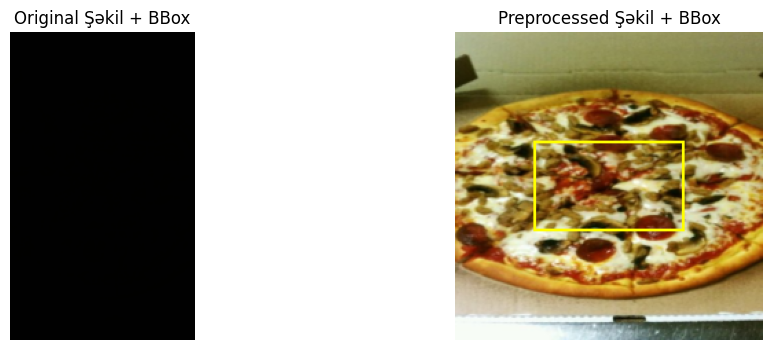

In [103]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)

# first_image_ts is already a torch.Tensor of uint8 in [C, H, W] format,
# which is suitable for torchvision.utils.draw_bounding_boxes.
image_with_bbox = get_image_with_bbox(first_image_ts, bbox)
plot_image(image_with_bbox)
plt.title('Original Şəkil + BBox')

plt.subplot(1, 2, 2)
image_with_bbox2 = get_image_with_bbox(denormalize(preproc_image), preproc_bbox, width=2, color="yellow")
plot_image(image_with_bbox2)
plt.title('Preprocessed Şəkil + BBox')
plt.show()

In [96]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

# Modeli yükləyirik
weights = FCN_ResNet50_Weights.DEFAULT
seg_model = fcn_resnet50(weights=weights)
seg_model.eval()
seg_model = seg_model.to(device)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:00<00:00, 184MB/s]


In [97]:
# Test şəklini yükləyirik (pizza şəkli)
img = Image.open(first_image_path).convert("RGB")
transform_seg = weights.transforms()
batch = transform_seg(img).unsqueeze(0).to(device)

In [98]:
# Seqmentasiya tətbiq edirik
with torch.no_grad():
    masks = seg_model(batch)["out"].softmax(dim=1)

# 'pizza' sinifini tapaq (COCO datasetində pizza sinif ID-si var)
class_names_seg = weights.meta["categories"]
# COCO-da pizza üçün birbaşa sinif yoxdur, amma 'food' və ya 'pizza' varsa istifadə edə bilərik
# Burada nümunə olaraq ən yüksək ehtimallı sinifi göstərəcəyik
mask = masks[0].argmax(dim=0) # ən yüksək ehtimallı sinif

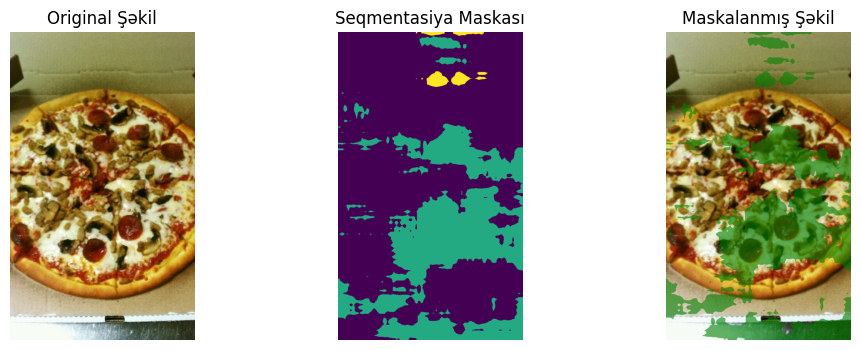

In [99]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axis('off')
plt.title('Original Şəkil')

plt.subplot(1, 3, 2)
plt.imshow(mask.cpu().numpy())
plt.axis('off')
plt.title('Seqmentasiya Maskası')

plt.subplot(1, 3, 3)
# Maskanı şəklin üzərinə əlavə edirik
# İlk olaraq, denormalize edilmiş şəkli əldə edirik
denorm_img = denormalize(batch.squeeze(0).cpu()) #-> (H, W) => [3, H, W]

# Maskadakı class ID-lərini vizuallaşdırmaq üçün bir rəng xəritəsi yaradaq
# Və ya daha sadə bir yanaşma ilə: background olmayan bütün pikselləri rəngləyək

# `mask` tensoru class indekslərini saxlayır, `mask != 0` foreground hissələri seçir.
binary_mask = (mask != 0) # [H, W] ölçüsündə boolean mask

# `torchvision.utils.draw_segmentation_masks` funksiyası üçün giriş şəkli uint8 olmalıdır
img_tensor_uint8 = (denorm_img * 255).to(torch.uint8)

# Maskanı yaşıl rəngdə göstərək
colors = ["green"]
# `masks` parametri üçün ölçü `(N, H, W)` olmalıdır, ona görə `unsqueeze(0)` istifadə edirik
masked_image_tensor = torchvision.utils.draw_segmentation_masks(
    img_tensor_uint8,
    masks=binary_mask.unsqueeze(0),
    alpha=0.6, # Maskanın şəffalıq dərəcəsi
    colors=colors
)

# plot_image funksiyası float tensor [0, 1] aralığında gözləyir
masked_image_for_plot = masked_image_tensor.float() / 255
plot_image(masked_image_for_plot)
plt.title('Maskalanmış Şəkil')
plt.show()